In [1]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time

import cartopy.crs as ccrs


In [2]:
ssplist = ["126","245","370","585"]
# ssplist = ["245","370","585"]

In [3]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

# historical_era = [1960,2000]
experiment_era = [1950,2100]
baselineera = [1900,1950]
# tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 5

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [4]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


What is the year that a period-period record maximum becomes more likely than not?

In [5]:
len(AllData.alloutput)

endhist = 2014

emergenceyear = np.empty((4,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

for ilatsel,latsel in enumerate(AllData.output_lat):
    print(latsel)
    for ilonsel,lonsel in enumerate(AllData.output_lon):

        if latsel<0:
            season = 2
        else:
            season = 8

        latindsel = np.argmin(np.abs((AllData.output_lat-latsel)))
        lonindsel = np.argmin(np.abs((AllData.output_lon-lonsel)))

        gmthistorical = [1960,1990]
        gmthistoricalinds = [gmthistorical[0]-AllData.timerange[0],gmthistorical[1]-AllData.timerange[0]]
        historicalinds = [experiment_era[0]-AllData.timerange[0],endhist-AllData.timerange[0]+outputavgtime]

        baselineindices = [baselineera[0]-AllData.timerange[0],baselineera[1]-AllData.timerange[0]]

        recordtemps = np.zeros((len(AllData.ssplist),AllData.alloutput[0].shape[0],AllData.alloutput[0].shape[1]))

        if season ==8:
            timevec = np.arange(experiment_era[0]+inputlength,2100-outputavgtime+2)
        elif season==2:
            timevec = np.arange(experiment_era[0]+inputlength,2100-outputavgtime+1)

        for issp,ssp in enumerate(AllData.ssplist):

            histsel = AllData.alloutput[issp]
            histsel = histsel[:,:,latindsel,lonindsel]

            baseline = np.max(histsel[:,baselineindices[0]:baselineindices[1]],axis=1)
            
            for iens in range(histsel.shape[0]):

                recordtemps[issp,iens,:] = DataHolder.find_records(histsel[iens,:],baseline[iens])

            output_recordtemps_hist = recordtemps[issp,:,historicalinds[0]:]
            # stack it
            stackedoutput = DataHolder.stackmatalongdim1(output_recordtemps_hist,outputavgtime)

                # cut it
            cutoutput = stackedoutput[:,inputlength:]
            # control for season
            if season==2:
                cutoutput = cutoutput[:,1:]
            # number of extremes in a future period

            nevents = np.sum(cutoutput,axis=2)
            outputrecordsummer = 1*(nevents>0) # any number >0 is a yes

            meanoutputrecord = np.mean(outputrecordsummer,axis=0)

            # yearind = np.argmin(np.abs(outputrecordsummer-0.5))
            yearind = np.where(meanoutputrecord > 0.5)[0]
            if len(yearind) > 0: 
                emergenceyear[issp,ilatsel,ilonsel] = timevec[yearind[0]]






-90
-80
-70
-60
-50
-40
-30
-20
-10
0
10
20
30
40
50
60
70
80


Text(0.5, 0, 'year')

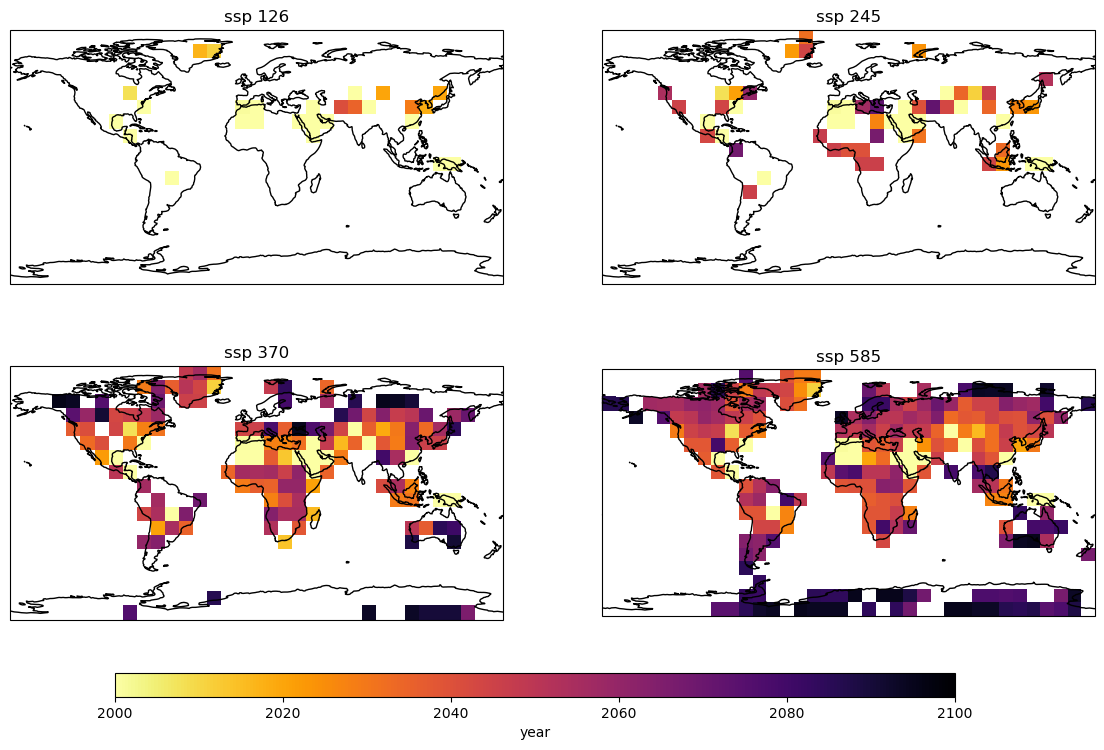

In [12]:
plt.figure(figsize=(14,8))

for iplot in range(4):
    a1=plt.subplot(2,2,iplot+1,projection=ccrs.PlateCarree())
    c1=a1.pcolormesh(AllData.output_lon+5,AllData.output_lat+5,emergenceyear[iplot],vmin=2000,vmax=2100,cmap='inferno_r')
    a1.coastlines()

    plt.title('ssp ' + ssplist[iplot])

cax = plt.axes((0.2,0.03,0.6,0.03))
cbar=plt.colorbar(c1,cax=cax,orientation='horizontal')

cbar.ax.set_xlabel('year')

In [9]:
latsel = 40
lonsel = 10


In [10]:
# plt.subplot(1,1,1)
allpred = []

imp.reload(buildmodel)

for iseed, seed in enumerate(seedlist[8:9]):

    torch.manual_seed(seed) 
    np.random.seed(seed)

    trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

    trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

    alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

    inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
    inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
    inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)
    
    outputvalclass = np.argmax(outputval.numpy(),axis=1)
    outputtestclass = np.argmax(outputtest.numpy(),axis=1)

    #baseline of beating gmt, need to get gmt
    # nullval,nulltest = AllData.calculate_nulls(trainvaltest)

    cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
    fileout = "models/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True, map_location=torch.device('cpu')))
    # cnn.to('mps')

    with torch.no_grad():
        cnn.eval()
        predval = cnn(inputval, inputvalGMT)
        predtest = cnn(inputtest, inputtestGMT)

    predvalclass = torch.argmax(predval, dim=1).numpy()
    # allpred.append(predval.numpy())

    predtestclass = torch.argmax(predtest, dim=1).numpy()

    acc = np.mean(predvalclass == outputvalclass)
    acctest = np.mean(predtestclass == outputtestclass)
    # gmtacc = np.mean(nullval == outputvalclass)

    # gmttestacc = np.mean(nulltest == outputtestclass)

    print("Seed ", str(seed), "val imbalance: ", str(1-np.mean(outputvalclass)))

    print("Seed ", str(seed), " val accuracy: ", str(acc))
    # print("Seed ", str(seed), " gmt val accuracy: ", str(gmtacc))

    print("Seed ", str(seed), "test imbalance: ", str(1-np.mean(outputtestclass)))
    print("Seed ", str(seed), " test accuracy: ", str(acctest))
    # print("Seed ", str(seed), " gmt test accuracy: ", str(gmttestacc))

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # predseed = allpred[iseed]
    # predseed = np.argmax(predseed, axis=1)
    # predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

    # predseedmean = np.mean(predseed, axis=0)
    # plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

    # for i in range(len(trainvaltest[2])):
    #     plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

    #     plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

# plt.plot(yearvec,avgeffectofGMT_test,color='xkcd:blue',label='GMT only',linewidth=1.3)
# plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)

# gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
# print("GMT only val accuracy: ", str(gmtonlyacc))

# plt.xlim(2000,2040)


baseline for gmt is 60 90
experiment era in the historical is 50 119
baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585
Seed  57693846 val imbalance:  0.7445573294629899
Seed  57693846  val accuracy:  0.7455940286128966
Seed  57693846 test imbalance:  0.7221473495058401
Seed  57693846  test accuracy:  0.731581311769991
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


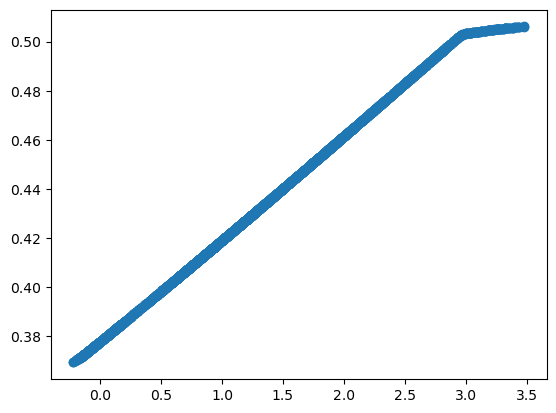

In [11]:
plt.scatter(inputvalGMT.numpy(),predval[:,1])

In [102]:
allsummer = []

for i in range(5):
    truesummer = AllData.truesummer[i][25:38].flatten()
    allsummer.extend(truesummer)

In [103]:
plt.scatter(allsummer,allpred[-1][:,1],c=inputvalGMT.numpy())
plt.colorbar()
# plt.vlines(np.mean(AllData.onesigmas),0,1,color='xkcd:grey',linestyle='dashed')

IndexError: list index out of range

(array([  29.,   90.,   83.,   53.,   73.,   64.,   57.,   50.,   60.,
        4199.]),
 array([0.40946433, 0.43088984, 0.45231539, 0.47374091, 0.49516642,
        0.51659197, 0.53801745, 0.559443  , 0.58086854, 0.60229403,
        0.62371957]),
 <BarContainer object of 10 artists>)

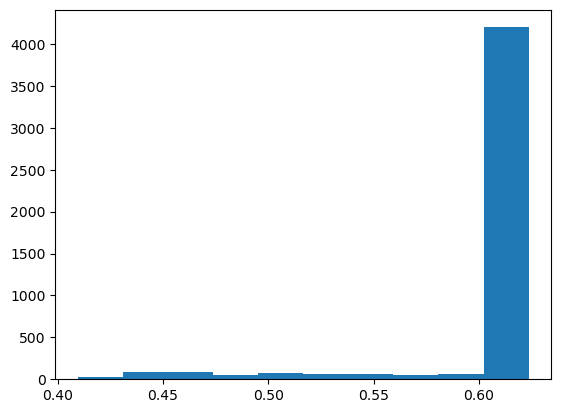

In [49]:
plt.hist(allpred[7][:,1])

In [82]:
cnn

CNNclassifier(
  (conv_layers): ModuleList(
    (0): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layers): ModuleList(
    (0): Linear(in_features=881, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=10, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=10, out_features=2, bias=True)
  (softmax): Softmax(dim=1)
)

In [51]:
AllData.truesummer[2].shape

(50, 78)

In [52]:
allpred[0][:,1].shape

(4758,)

In [53]:
confusion_mat = np.empty((2,2))
confusion_mat_gmt = np.empty((2,2))

for i in range(2):
    for j in range(2):

        confusion_mat[i,j] = np.mean(1*((predvalclass==i) & (outputvalclass==j)))
        # confusion_mat_gmt[i,j] = np.mean(1*((nullval==i) & (outputvalclass==j)))

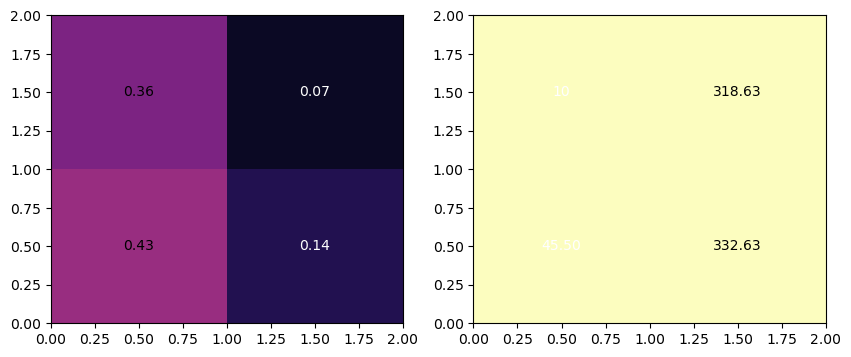

In [54]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
im1 = plt.pcolormesh(np.flipud(confusion_mat),vmin=0,vmax=1,cmap='magma')
nrows, ncols = confusion_mat.shape
for i in range(nrows):
    for j in range(ncols):
        val = confusion_mat[i, j]
        if abs(val - round(val)) < 1e-8:
            s = str(int(round(val)))
        else:
            s = "{:.2f}".format(val)
        x = j + 0.5
        y = nrows - i - 0.5
        text_color = 'white' if val < (confusion_mat.max() / 2.0) else 'black'
        plt.text(x, y, s, ha='center', va='center', color=text_color)


plt.subplot(1,2,2)
plt.pcolormesh(np.flipud(confusion_mat_gmt),vmin=0,vmax=1,cmap='magma')
nrows2, ncols2 = confusion_mat_gmt.shape
for i in range(nrows2):
    for j in range(ncols2):
        val = confusion_mat_gmt[i, j]
        if abs(val - round(val)) < 1e-8:
            s = str(int(round(val)))
        else:
            s = "{:.2f}".format(val)
        x = j + 0.5
        y = nrows2 - i - 0.5
        text_color = 'white' if val < (confusion_mat_gmt.max() / 2.0) else 'black'
        plt.text(x, y, s, ha='center', va='center', color=text_color)

In [55]:
f1score = 2*confusion_mat[1,1]/(2*confusion_mat[1,1] + confusion_mat[1,0] + confusion_mat[0,1])
print(f1score)

f1score_gmt = 2*confusion_mat_gmt[1,1]/(2*confusion_mat_gmt[1,1] + confusion_mat_gmt[1,0] + confusion_mat_gmt[0,1])
print(f1score_gmt)

0.3682658804610024
0.6462659626516255


In [81]:
trainvaltest

[array([21, 33,  9, 31,  3, 28, 25, 29, 27, 10, 18, 36,  7, 37, 12,  5, 23,
        22, 20, 34, 13, 26, 24, 14, 16]),
 array([35, 11,  0, 19, 17,  4,  1, 15,  6,  8,  2, 30, 32]),
 array([38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])]